In [ ]:
import os

import numpy as np
import pandas as pd
import plotnine as p9
from IPython import get_ipython
from sklearn.metrics import (
  classification_report,
  confusion_matrix,
)
from sklearn.model_selection import KFold, train_test_split
from vinesforest import VinesForest

import pyvinecopulib as pv

ipython = get_ipython()

# Display plots inline in Jupyter Notebook
ipython.run_line_magic("matplotlib", "inline")

# Minimal reporting for exception handlers
ipython.run_line_magic("xmode", "minimal")

# Automatically reload modules when they have changed
ipython.run_line_magic("load_ext", "autoreload")
ipython.run_line_magic("autoreload", "2")

# Display all output from a cell (not just the last line)
ipython.run_line_magic(
  "config", "InteractiveShell.ast_node_interactivity='all'"
)

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", None)
pd.set_option("display.precision", 3)

# Numpy settings
np.printoptions(
  precision=4,
  suppress=True,
  formatter={"float": "{:0.4f}".format},
  linewidth=80,
)

Exception reporting mode: Minimal
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


0.6866249308666146 0.7327259930817038
1.1600854940018444 0.881213414638932


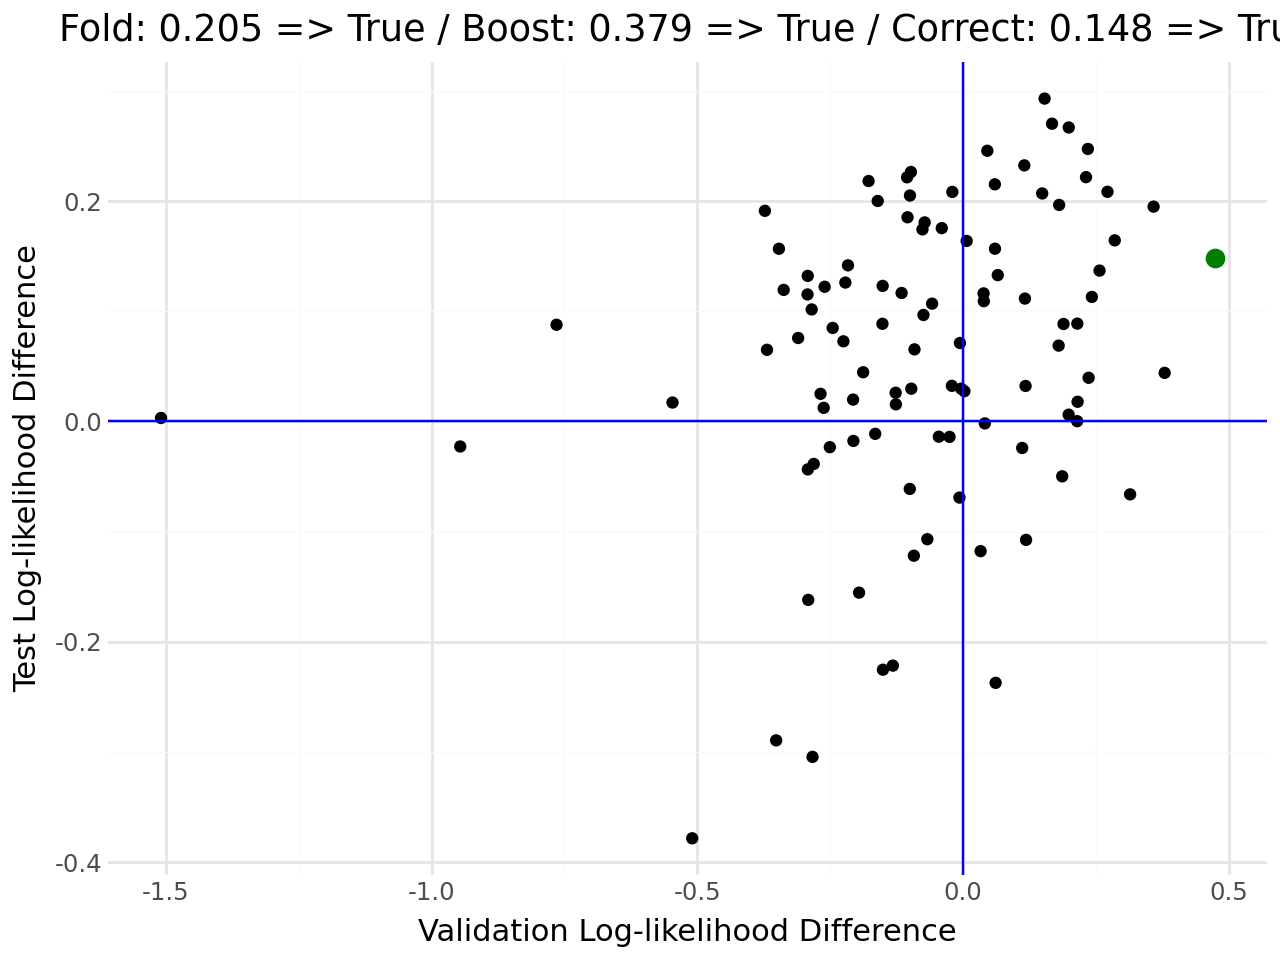

[[25  1]
 [70  4]]
              precision    recall  f1-score   support

       False       0.26      0.96      0.41        26
        True       0.80      0.05      0.10        74

    accuracy                           0.29       100
   macro avg       0.53      0.51      0.26       100
weighted avg       0.66      0.29      0.18       100



In [ ]:
n_vines = 100
seed = 12
train_size = 0.5
train_val_split = 0.75
num_threads = min(32, os.cpu_count() + 4)
grid_size = 30

data_name = "uranium"
data = pd.read_csv(f"data/{data_name}.csv")
if data_name == "magic":
  selected_class = "g"
  data = (
    data[data["class"] == selected_class]
    .drop(columns=["class"])
    .sample(n=5000, random_state=seed)
  )
if (data.values < 0).any() or (data.values > 1).any():
  data[data.columns] = pv.to_pseudo_obs(data.values)


controls = pv.FitControlsVinecop(
  family_set=[pv.tll],
  num_threads=num_threads,
  nonparametric_grid_size=grid_size,
)

data_train, data_test = train_test_split(
  data, train_size=train_size, random_state=seed
)

forest = VinesForest(
  n_vines=n_vines,
  seed=seed,
  controls=controls,
)
forest.fit(data_train.values)

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=seed)
means = []
for _, val_index in kf.split(forest.logliks_forest.T):
  means.append(forest.logliks_forest[:, val_index].mean(axis=1))

means_kfold = np.array(means)

B = 200

W = np.random.exponential(
  scale=1.0, size=(B, forest.logliks_forest.shape[1])
)  # (B, n_valid)
W /= W.sum(axis=1, keepdims=True)  # row-normalize weights

# Each row of the result is the weighted column means for one bootstrap draw
means_boot = W @ forest.logliks_forest.T  # shape: (B, n_models)


loglik_val_forest = forest.logliks_forest.mean(axis=1)
loglik_val_dissman = forest.loglik_dissman.mean()
corrected_kfold = (
  2 * max(loglik_val_forest)
  - np.array(means_kfold).max(axis=1).mean()
  - loglik_val_dissman
)
corrected_boot = (
  2 * max(loglik_val_forest)
  - np.array(means_boot).max(axis=1).mean()
  - loglik_val_dissman
)


loglik_dissman_test = np.log(forest.vine_dissman.pdf(data_test.values)).mean()
loglik_forest_test = (
  np.array([vine.loglik(data_test.values) for vine in forest.vines])
  / data_test.shape[0]
)


results = pd.DataFrame(
  {
    "loglik_val_diff": loglik_val_forest - loglik_val_dissman,
    "loglik_test_diff": loglik_forest_test - loglik_dissman_test,
  }
)

best_vine = results["loglik_val_diff"].idxmax()
print(loglik_val_dissman, loglik_dissman_test)
print(loglik_val_forest[best_vine], loglik_forest_test[best_vine])

correct_decision_kfold = (
  (corrected_kfold > 0)
  and (loglik_forest_test[best_vine] > loglik_dissman_test)
) or (
  (corrected_kfold <= 0)
  and (loglik_forest_test[best_vine] <= loglik_dissman_test)
)
correct_decision_boost = (
  (corrected_boot > 0) and (loglik_forest_test[best_vine] > loglik_dissman_test)
) or (
  (corrected_boot <= 0)
  and (loglik_forest_test[best_vine] <= loglik_dissman_test)
)

# Plot log-likelihood differences against test log-likelihoods
(
  p9.ggplot(
    results[results.index != best_vine],
    p9.aes(x="loglik_val_diff", y="loglik_test_diff"),
  )
  + p9.geom_point()
  + p9.geom_hline(yintercept=0, color="blue")
  + p9.geom_vline(xintercept=0, color="blue")
  + p9.geom_point(
    data=results[results.index == best_vine],
    color="green" if correct_decision_boost else "red",
    size=3,
  )
  + p9.labs(
    title=f"Fold: {corrected_kfold:.3f} => {corrected_kfold > 0} / Boost: {corrected_boot:.3f} => {corrected_boot > 0} / Correct: {loglik_forest_test[best_vine] - loglik_dissman_test:.3f} => {loglik_forest_test[best_vine] > loglik_dissman_test}",
    x="Validation Log-likelihood Difference",
    y="Test Log-likelihood Difference",
  )
  + p9.theme_minimal()
)


y_pred = (
  2 * loglik_val_forest
  - np.array(means_boot).max(axis=1).mean()
  - loglik_val_dissman
) > 0
y_true = results["loglik_test_diff"] > 0

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

In [ ]:
correct_decision = (
  (corrected_boot > 0) and (loglik_forest_test[best_vine] > loglik_dissman_test)
) or (
  (corrected_boot <= 0)
  and (loglik_forest_test[best_vine] <= loglik_dissman_test)
)

# Plot log-likelihood differences against test log-likelihoods
(
  p9.ggplot(
    results[results.index != best_vine],
    p9.aes(x="loglik_val_diff", y="loglik_test_diff"),
  )
  + p9.geom_point()
  + p9.geom_hline(yintercept=0, color="blue")
  + p9.geom_vline(xintercept=0, color="blue")
  + p9.geom_point(
    data=results[results.index == best_vine],
    color="green" if correct_decision else "red",
    size=3,
  )
  + p9.labs(
    title=f"Decision threshold: {corrected_boot:.4f} => {corrected_boot > 0} / {loglik_forest_test[best_vine] > loglik_dissman_test}",
    x="Validation Log-likelihood Difference",
    y="Test Log-likelihood Difference",
  )
  + p9.theme_minimal()
)


y_pred = (
  2 * loglik_val_forest
  - np.array(means).max(axis=1).mean()
  - loglik_val_dissman
) > 0
y_true = results["loglik_test_diff"] > 0

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

NameError: name 'corrected_boot' is not defined

In [ ]:
# print(top_k_accuracy_score(y_true, y_score, k=1, normalize=False))

# display = RocCurveDisplay.from_predictions(
#   y_true,
#   y_score,
#   curve_kwargs=dict(color="darkorange"),
#   plot_chance_level=True,
#   despine=True,
# )

[[96  0]
 [ 3  1]]
              precision    recall  f1-score   support

       False       0.97      1.00      0.98        96
        True       1.00      0.25      0.40         4

    accuracy                           0.97       100
   macro avg       0.98      0.62      0.69       100
weighted avg       0.97      0.97      0.96       100

